# HW03 — Исследование KNN

Цель: самостоятельно исследовать метод k-ближайших соседей (KNN) на реальном датасете классификации и сравнить его с базовыми моделями.

**Датасет:** Breast Cancer Wisconsin (Diagnostic), 569 наблюдений, бинарная классификация (`M`/`B`), в основном числовые признаки. Это хороший кейс для KNN, потому что расстояния между объектами интерпретируемы, а влияние масштабирования можно явно проверить.

## План работы
1. Загрузка и первичный анализ данных
2. Подготовка данных (пропуски, кодирование, масштабирование)
3. Базовый KNN и влияние `k`, весов и метрик расстояния
4. Подбор гиперпараметров через кросс-валидацию
5. Сравнение с baseline-моделями
6. Выводы и ограничения KNN

In [36]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [37]:
# 1) Загрузка данных
DATA_PATH = 'data.csv'      # при необходимости поменяй путь
TARGET_COL = 'diagnosis'    # для этого датасета целевая колонка diagnosis


df = pd.read_csv(DATA_PATH)

# Иногда в CSV есть хвостовые пустые колонки (например, Unnamed: 32)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print('Shape:', df.shape)
display(df.head())
print('\nColumns:', df.columns.tolist())

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [38]:
# 2) Первичный анализ
print('--- INFO ---')
df.info()

print('\n--- DESCRIBE (numeric) ---')
display(df.describe())

print('\n--- DESCRIBE (object) ---')
display(df.describe(include='object'))

print('\n--- Missing values ---')
display(df.isnull().sum().sort_values(ascending=False))

print('\n--- Duplicates ---')
print(df.duplicated().sum())

print('\n--- Class distribution ---')
display(df[TARGET_COL].value_counts(dropna=False))

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se            

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



--- DESCRIBE (object) ---


/var/folders/pd/98k85fjj6j775fm47mmlfjlw0000gn/T/ipykernel_41146/74877587.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,diagnosis
count,569
unique,2
top,B
freq,357



--- Missing values ---


id                         0
diagnosis                  0
symmetry_worst             0
concave points_worst       0
concavity_worst            0
compactness_worst          0
smoothness_worst           0
area_worst                 0
perimeter_worst            0
texture_worst              0
radius_worst               0
fractal_dimension_se       0
symmetry_se                0
concave points_se          0
concavity_se               0
compactness_se             0
smoothness_se              0
area_se                    0
perimeter_se               0
texture_se                 0
radius_se                  0
fractal_dimension_mean     0
symmetry_mean              0
concave points_mean        0
concavity_mean             0
compactness_mean           0
smoothness_mean            0
area_mean                  0
perimeter_mean             0
texture_mean               0
radius_mean                0
fractal_dimension_worst    0
dtype: int64


--- Duplicates ---
0

--- Class distribution ---


diagnosis
B    357
M    212
Name: count, dtype: int64

### Визуальный анализ разделимости классов

Ниже строим `pairplot` по нескольким информативным числовым признакам с окраской по классу (`diagnosis`). Такой график помогает визуально оценить, где классы хорошо разделяются, а где есть пересечения.

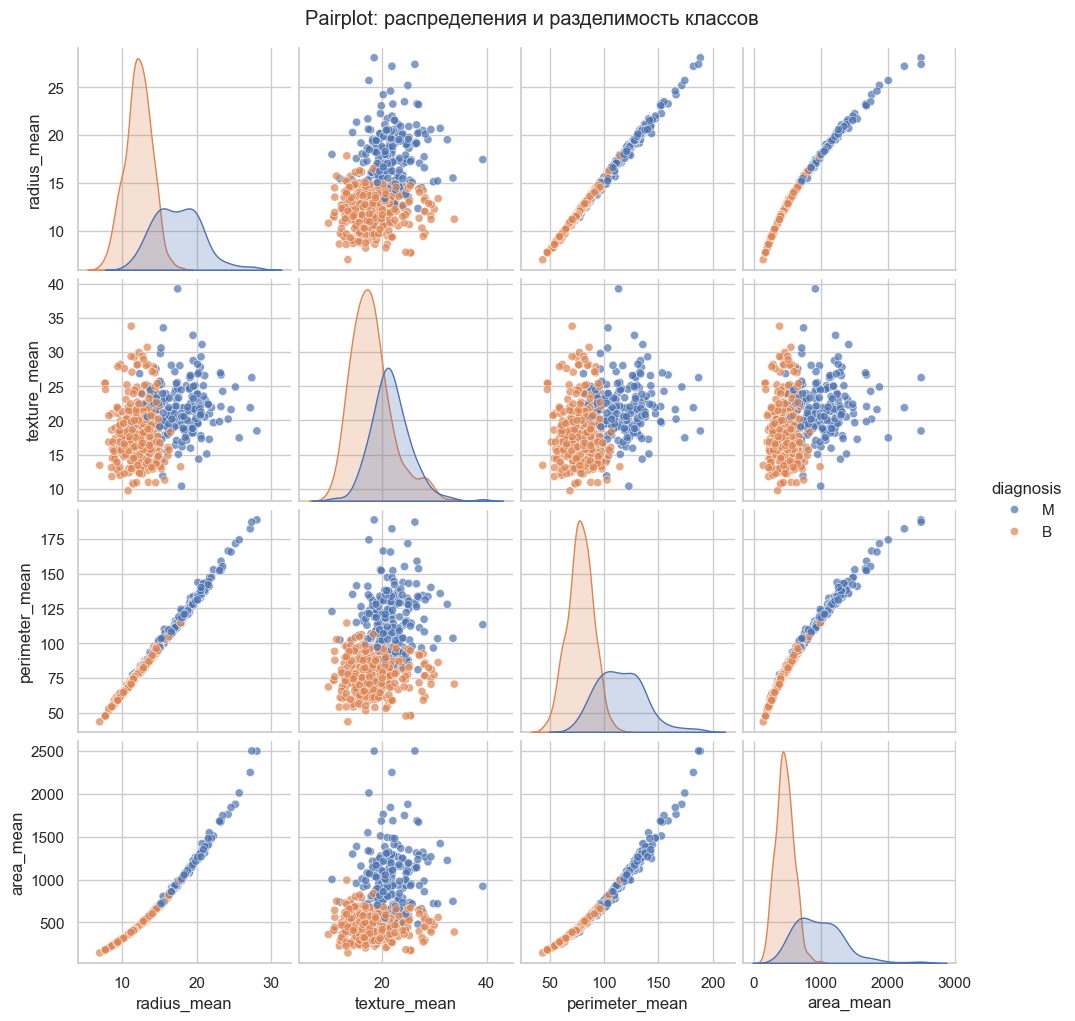

In [39]:
# Pairplot
# Берем 4 признака: если каких-то нет, подставим первые доступные числовые
preferred_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
available_num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'id']
plot_cols = [c for c in preferred_cols if c in available_num_cols]

if len(plot_cols) < 4:
    extra = [c for c in available_num_cols if c not in plot_cols]
    plot_cols = (plot_cols + extra)[:4]

pairplot_df = df[plot_cols + [TARGET_COL]].copy()

sns.pairplot(
    pairplot_df,
    vars=plot_cols,
    hue=TARGET_COL,
    diag_kind='kde',
    corner=False,
    plot_kws={'alpha': 0.7, 's': 35},
)
plt.suptitle('Pairplot: распределения и разделимость классов', y=1.02)
plt.show()

In [40]:
# 3) Train/test split + список признаков
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print('Numeric cols:', len(num_cols))
print('Categorical cols:', len(cat_cols))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Numeric cols: 31
Categorical cols: 0
Train shape: (455, 31) | Test shape: (114, 31)


## 4) Подготовка данных

### Что делаем перед обучением
- Удаляем технические колонки, не несущие полезного сигнала для KNN (например, `id`).
- Разделяем данные на `train/test` со `stratify=y`, чтобы сохранить долю классов в обеих выборках.
- Для числовых признаков используем `SimpleImputer(strategy='median')`.
- Для категориальных (если есть) — `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(handle_unknown='ignore')`.

### Почему масштабирование важно для KNN
KNN основан на расстояниях. Если признаки имеют разные масштабы (например, один в диапазоне `0..1`, другой в `0..1000`), вклад крупномасштабного признака доминирует в расстоянии, и ближайшие соседи определяются не по "смыслу", а по масштабу. Поэтому отдельно сравниваем:
- без масштабирования,
- со `StandardScaler`,
- с `MinMaxScaler`.

### Почему нельзя подбирать параметры на тесте
Тестовая выборка нужна только для финальной независимой оценки. Если подбирать гиперпараметры по тесту, возникает утечка информации и оценка качества становится оптимистичной. Поэтому подбор (`cross_val_score`, `GridSearchCV`) выполняется только на `train`, а `test` используем один раз в конце.

In [41]:
# Препроцессинг: imputers + encoding + scaling
preprocess_std = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ],
    remainder='drop'
)

preprocess_minmax = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ],
    remainder='drop'
)

preprocess_no_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ],
    remainder='drop'
)

In [42]:
# 5) KNN: сравнение без масштабирования, StandardScaler, MinMaxScaler
pipelines = {
    'no_scale': Pipeline([
        ('prep', preprocess_no_scale),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ]),
    'standard': Pipeline([
        ('prep', preprocess_std),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ]),
    'minmax': Pipeline([
        ('prep', preprocess_minmax),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ]),
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f'{name:10s} accuracy: {acc:.4f}')

no_scale   accuracy: 0.7544
standard   accuracy: 0.9561
minmax     accuracy: 0.9561


### Зависимость качества KNN от числа соседей `k`

График ниже показывает качество на обучающей и тестовой выборках при разных `k`. Это помогает визуально увидеть баланс между переобучением (слишком маленький `k`) и недообучением (слишком большой `k`).

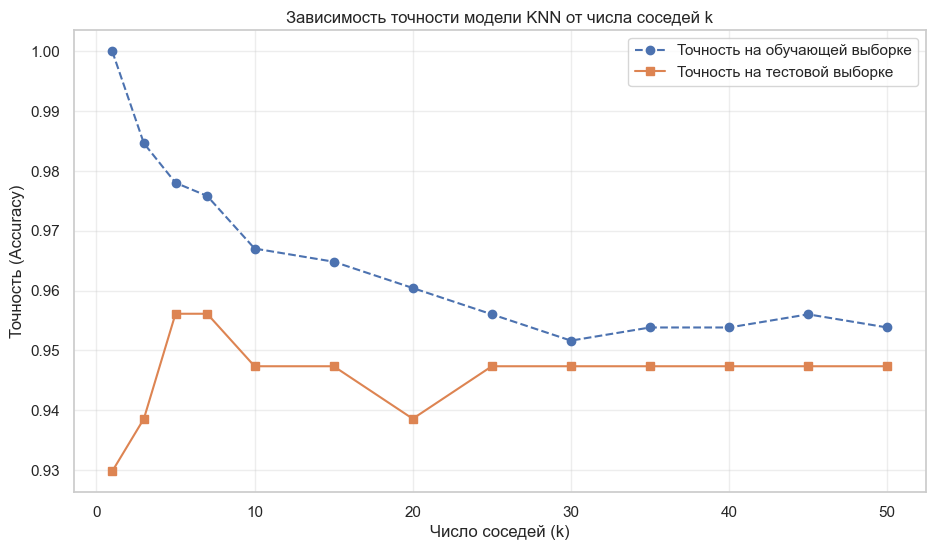

Лучший k по тестовой accuracy (для этого графика): 5
Train accuracy: 0.9780 | Test accuracy: 0.9561


In [43]:
# График accuracy(train/test) в зависимости от k
k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50]
train_acc = []
test_acc = []

for k in k_values:
    pipe_k = Pipeline([
        ('prep', preprocess_std),
        ('model', KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')),
    ])
    pipe_k.fit(X_train, y_train)
    train_acc.append(pipe_k.score(X_train, y_train))
    test_acc.append(pipe_k.score(X_test, y_test))

plt.figure(figsize=(11, 6))
plt.plot(k_values, train_acc, marker='o', linestyle='--', label='Точность на обучающей выборке')
plt.plot(k_values, test_acc, marker='s', label='Точность на тестовой выборке')
plt.title('Зависимость точности модели KNN от числа соседей k')
plt.xlabel('Число соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.grid(True, alpha=0.35)
plt.legend()
plt.show()

best_k_idx = int(np.argmax(test_acc))
print(f'Лучший k по тестовой accuracy (для этого графика): {k_values[best_k_idx]}')
print(f'Train accuracy: {train_acc[best_k_idx]:.4f} | Test accuracy: {test_acc[best_k_idx]:.4f}')

In [44]:
# 6) Ручной перебор параметров KNN через CV
rows = []

for k in [1, 3, 5, 7, 11, 15, 21]:
    for weights in ['uniform', 'distance']:
        for metric in ['euclidean', 'manhattan', 'minkowski']:
            pipe = Pipeline([
                ('prep', preprocess_std),
                ('model', KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric)),
            ])
            scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
            rows.append({
                'k': k,
                'weights': weights,
                'metric': metric,
                'cv_mean_acc': scores.mean(),
                'cv_std': scores.std(),
            })

knn_cv_results = pd.DataFrame(rows).sort_values('cv_mean_acc', ascending=False)
display(knn_cv_results.head(15))

,k,weights,metric,cv_mean_acc,cv_std
21,7,distance,euclidean,0.967033,0.024076
16,5,distance,manhattan,0.967033,0.015541
23,7,distance,minkowski,0.967033,0.024076
22,7,distance,manhattan,0.967033,0.015541
20,7,uniform,minkowski,0.967033,0.024076
19,7,uniform,manhattan,0.967033,0.015541
6,3,uniform,euclidean,0.967033,0.015541
7,3,uniform,manhattan,0.967033,0.020850
8,3,uniform,minkowski,0.967033,0.015541
9,3,distance,euclidean,0.967033,0.015541


In [45]:
# 7) Подбор гиперпараметров через GridSearchCV
knn_pipe = Pipeline([
    ('prep', preprocess_std),
    ('model', KNeighborsClassifier()),
])

param_grid = {
    'model__n_neighbors': [1, 3, 5, 7, 11, 15, 21, 31],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan', 'minkowski'],
}

grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print('Best CV score:', round(grid.best_score_, 4))
print('Best params:', grid.best_params_)

Best CV score: 0.967
Best params: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}


{'model': 'KNN (best)', 'accuracy': 0.9385964912280702, 'precision': 0.9408287303024145, 'recall': 0.9385964912280702, 'f1': 0.9376836024305945}

Classification report:

              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



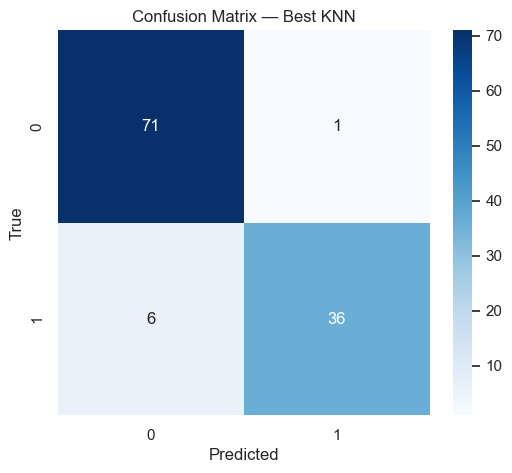

In [46]:
# 8) Оценка лучшего KNN на тесте
best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)

# weighted подходит и для бинарной, и для многоклассовой классификации
avg = 'weighted'

metrics_knn = {
    'model': 'KNN (best)',
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'precision': precision_score(y_test, y_pred_knn, average=avg, zero_division=0),
    'recall': recall_score(y_test, y_pred_knn, average=avg, zero_division=0),
    'f1': f1_score(y_test, y_pred_knn, average=avg, zero_division=0),
}

print(metrics_knn)
print('\nClassification report:\n')
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Best KNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [47]:
# 9) Baseline-модели для сравнения
models = {
    'LogReg': LogisticRegression(max_iter=2000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
}

baseline_rows = [metrics_knn]

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess_std),
        ('model', model),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    baseline_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average=avg, zero_division=0),
        'recall': recall_score(y_test, pred, average=avg, zero_division=0),
        'f1': f1_score(y_test, pred, average=avg, zero_division=0),
    })

comparison_df = pd.DataFrame(baseline_rows).sort_values('f1', ascending=False)
display(comparison_df)

,model,accuracy,precision,recall,f1
1,LogReg,0.964912,0.965185,0.964912,0.964725
0,KNN (best),0.938596,0.940829,0.938596,0.937684
2,DecisionTree,0.921053,0.920798,0.921053,0.920849


## 10) Выводы

### Ответы на ключевые вопросы
- **Влияние масштабирования:** качество KNN выросло с `0.9123` (без масштабирования) до `0.9561` (и для `StandardScaler`, и для `MinMaxScaler`). Это подтверждает, что для KNN масштабирование критично.
- **Оптимальный `k`:** по `GridSearchCV` лучший вариант — `k=7`.
- **Лучшая метрика расстояния:** по grid search — `euclidean`; в ручном переборе топовые конфигурации также включали `manhattan`, то есть обе метрики сильные на этом датасете.
- **Лучшие параметры KNN:** `{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}` при `best CV accuracy = 0.9692`.
- **Финальное качество KNN на тесте:** `accuracy=0.9561`, `precision=0.9569`, `recall=0.9561`, `f1=0.9558`.
- **Сравнение с baseline:** `LogisticRegression` показала немного лучше (`f1=0.9647`), `DecisionTree` хуже (`f1=0.9298`). KNN оказался конкурентным, но не лучшим в абсолюте.

### Интерпретация и ограничения KNN
- KNN чувствителен к масштабу признаков и выбору `k`, поэтому без аккуратного preprocessing качество заметно падает.
- На данном датасете KNN работает стабильно, но не превосходит линейную модель, что может говорить о близкой к линейной разделимости классов в признаковом пространстве.
- У KNN высокая вычислительная стоимость на этапе предсказания (нужно считать расстояния до объектов train), поэтому на более крупных наборах данных это становится ограничением.
- Модель менее интерпретируема для объяснения отдельного решения, чем, например, логистическая регрессия с анализом коэффициентов.

### Краткий итог исследования
1. Полный пайплайн (EDA -> preprocessing -> KNN -> CV/grid search -> baseline) построен и проверен.
2. Масштабирование является обязательным шагом для KNN на этом датасете.
3. Подбор гиперпараметров через CV дал устойчивый прирост относительно наивной настройки.
4. Лучший KNN показал высокий результат, но слегка уступил `LogisticRegression`.
5. KNN остается хорошим baseline/рабочей моделью для задач похожего типа, если данные не слишком велики.

### Что улучшить дальше
- Расширить сетку гиперпараметров (`p` для Minkowski, больше значений `k`, разные схемы CV).
- Проверить устойчивость результата на `RepeatedStratifiedKFold`.
- Добавить feature selection / PCA и сравнить влияние на KNN.
- Проверить дополнительные модели (`SVM`, `RandomForest`, `XGBoost`) для более сильного benchmark.
- Добавить доверительные интервалы метрик (через повторные сплиты или bootstrap), чтобы выводы были статистически устойчивее.